In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

/home/sahil/Desktop/LANGGRAPH/myenv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [14]:
#defien state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [15]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)

    return state


In [16]:
def label_bmi_category(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 25:
        category = 'Normal weight'
    elif 25 <= bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obese'

    state['category'] = category

    return state    

In [17]:
#define your graph
graph = StateGraph(BMIState)

#add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi_category', label_bmi_category)  # Placeholder for the next step

#add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi_category')
graph.add_edge('label_bmi_category', END)

#compile your graph
workflow = graph.compile()

In [23]:
#execute your graph
initial_state = {
    'weight_kg': 74,
    'height_m': 1.72
}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 74, 'height_m': 1.72, 'bmi': 25.01, 'category': 'Overweight'}


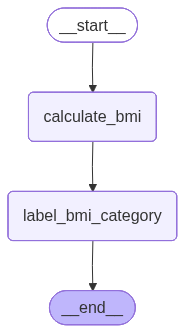

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())